# Eksperimen 13 — Calibration & Fusion Optimization (Isolasi Label Smoothing)

Notebook ini memuat dan memvisualisasikan hasil training & evaluasi Eksperimen 13.

Target utama eksperimen ini adalah **mengisolasi kontribusi label smoothing terhadap ECE (Expected Calibration Error) dan Brier Score**. Kami menonaktifkan label smoothing (label smoothing = 0.00) untuk melihat efeknya terhadap kalibrasi probabilitas biner, sementara weight decay dikunci pada baseline (weight decay = 2e-3).

| | |
|---|---|
| **Model** | EfficientNetV2-S (Binary Classification) |
| **View** | Front + Side |
| **Fusion** | Average & Adaptive (confidence-based) |
| **Versi Eksperimen** | Eksperimen 13 (Calibration & Fusion: Weight Decay = 2e-3, Label Smoothing = 0.00) |

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────────
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns

# Tambahkan root project ke path agar bisa import src.*
PROJECT_ROOT = Path("../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"

# Style
plt.style.use("seaborn-v0_8-darkgrid")
COLORS = {"front": "#4C9BE8", "side": "#E8834C", "avg": "#6FCB9F", "adapt": "#A78BFA"}

print("✅ Setup selesai. Project root:", PROJECT_ROOT)

✅ Setup selesai. Project root: D:\Skripsi\Experiment


## 0. Perbandingan Konfigurasi (Eksperimen 12 → Eksperimen 13)

Tabel perbandingan parameter untuk melihat arah optimasi:

In [2]:
# ── Tampilkan diff konfigurasi eksperimen ───────────────────────────────────
config_diff = [
    {"Parameter": "WEIGHT_DECAY", "Exp 12 (Baseline)": "2e-3", "Exp 13 (Calibration & Fusion)": "2e-3 (Locked)", "Alasan": "Mempertahankan baseline weight decay untuk mengisolasi efek LS"},
    {"Parameter": "LABEL_SMOOTHING", "Exp 12 (Baseline)": "0.12", "Exp 13 (Calibration & Fusion)": "0.0", "Alasan": "Dinonaktifkan agar tidak mendistorsi probabilitas biner"},
    {"Parameter": "DROPOUT_FRONT", "Exp 12 (Baseline)": "0.5", "Exp 13 (Calibration & Fusion)": "0.5 (Locked)", "Alasan": "Mempertahankan baseline front view"},
    {"Parameter": "EARLY_STOPPING_PATIENCE_FRONT", "Exp 12 (Baseline)": "3", "Exp 13 (Calibration & Fusion)": "3 (Locked)", "Alasan": "Mempertahankan baseline front view"},
    {"Parameter": "DROPOUT_SIDE", "Exp 12 (Baseline)": "0.3", "Exp 13 (Calibration & Fusion)": "0.3 (Locked)", "Alasan": "Mempertahankan baseline side view"},
    {"Parameter": "EARLY_STOPPING_PATIENCE_SIDE", "Exp 12 (Baseline)": "7", "Exp 13 (Calibration & Fusion)": "7 (Locked)", "Alasan": "Mempertahankan baseline side view"},
    {"Parameter": "NUM_STAGES_TO_FREEZE_SIDE", "Exp 12 (Baseline)": "4", "Exp 13 (Calibration & Fusion)": "4 (Locked)", "Alasan": "Mempertahankan level freezing side view"},
    {"Parameter": "AUG_COLOR_JITTER_FACTOR", "Exp 12 (Baseline)": "0.8", "Exp 13 (Calibration & Fusion)": "0.8 (Locked)", "Alasan": "Mempertahankan baseline augmentasi"}
]

import pandas as pd
df_config = pd.DataFrame(config_diff)
display(df_config.style
    .set_properties(**{"text-align": "left"})
    .set_caption("Perbandingan Konfigurasi Parameter Eksperimen 12 dan 13")
    .hide(axis="index"))

Parameter,Exp 12 (Baseline),Exp 13 (Calibration & Fusion),Alasan
WEIGHT_DECAY,2e-3,2e-3 (Locked),Mempertahankan baseline weight decay untuk mengisolasi efek LS
LABEL_SMOOTHING,0.12,0.0,Dinonaktifkan agar tidak mendistorsi probabilitas biner
DROPOUT_FRONT,0.5,0.5 (Locked),Mempertahankan baseline front view
EARLY_STOPPING_PATIENCE_FRONT,3,3 (Locked),Mempertahankan baseline front view
DROPOUT_SIDE,0.3,0.3 (Locked),Mempertahankan baseline side view
EARLY_STOPPING_PATIENCE_SIDE,7,7 (Locked),Mempertahankan baseline side view
NUM_STAGES_TO_FREEZE_SIDE,4,4 (Locked),Mempertahankan level freezing side view
AUG_COLOR_JITTER_FACTOR,0.8,0.8 (Locked),Mempertahankan baseline augmentasi


## 0.5. Otomatisasi Training & Evaluasi (Google Colab Experience)

Ubah `RUN_RETRAINING` di bawah ini menjadi `True` jika kamu ingin melatih ulang model M_front dan M_side dengan konfigurasi Eksperimen 13 secara otomatis dengan log mengalir real-time.

In [3]:
# ⚠️ PENTING: Set ke True hanya jika ingin melakukan re-training (memakan waktu beberapa menit/jam tergantung GPU)
RUN_RETRAINING = False

import subprocess
import os

def run_command_live(cmd_args, cwd=None):
    """Menjalankan perintah OS secara live dan mengalirkan outputnya langsung ke Jupyter notebook."""
    env = os.environ.copy()
    env["PYTHONIOENCODING"] = "utf-8"
    env["PYTHONUNBUFFERED"] = "1"
    
    # Menjalankan subprocess
    process = subprocess.Popen(
        cmd_args,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,  # Gabungkan stderr ke stdout
        text=True,
        encoding="utf-8",
        cwd=cwd,
        env=env
    )
    
    # Baca output baris demi baris secara real-time
    while True:
        output = process.stdout.readline()
        if output == '' and process.poll() is not None:
            break
        if output:
            print(output, end='', flush=True)


In [4]:
if RUN_RETRAINING:
    # Tentukan executable python di dalam virtual environment (.venv)
    python_exe = str(PROJECT_ROOT / ".venv" / "Scripts" / "python.exe")
    if not os.path.exists(python_exe):
        python_exe = "python"  # Fallback jika venv tidak terdeteksi
        
    print("🚀 Memulai Retraining Model (Eksperimen 13 — Calibration & Fusion Optimization (Isolasi Label Smoothing))...\n")
    
    print("1/3 [FRONT VIEW] Melatih model (dropout = 0.5, weight_decay = 2e-3, patience = 3, label_smoothing = 0.00)...\n")
    run_command_live([python_exe, "-m", "src.train", "--view", "front"], cwd=PROJECT_ROOT)
    
    print("\n2/3 [SIDE VIEW] Melatih model (dropout = 0.3, weight_decay = 2e-3, patience = 7, label_smoothing = 0.00)...\n")
    run_command_live([python_exe, "-m", "src.train", "--view", "side"], cwd=PROJECT_ROOT)
    
    print("\n3/4 [SINGLE-VIEW EVALUATION] Mengevaluasi model front & side...\n")
    run_command_live([python_exe, "-m", "src.evaluate"], cwd=PROJECT_ROOT)
    
    print("\n4/4 [FUSION & EVALUATION] Menjalankan fusion...\n")
    run_command_live([python_exe, "-m", "src.fusion"], cwd=PROJECT_ROOT)
    
    print("\n✅ Re-training selesai! Seluruh hasil di folder results/ telah terupdate.")
else:
    print("ℹ️ Re-training dilewati (RUN_RETRAINING = False).")
    print("   Notebook akan memvisualisasikan data yang sudah ada di folder results/.")


ℹ️ Re-training dilewati (RUN_RETRAINING = False).
   Notebook akan memvisualisasikan data yang sudah ada di folder results/.


## 1. Load Hasil Eksperimen

In [5]:
# ── Load semua file JSON hasil training & fusion ───────────────────────────────
with open(RESULTS_DIR / "front_history.json") as f:
    hist_front = json.load(f)

with open(RESULTS_DIR / "side_history.json") as f:
    hist_side = json.load(f)

with open(RESULTS_DIR / "front_test_metrics.json") as f:
    metrics_front = json.load(f)

with open(RESULTS_DIR / "side_test_metrics.json") as f:
    metrics_side = json.load(f)

with open(RESULTS_DIR / "fusion_comparison.json") as f:
    fusion = json.load(f)

print(f"Front training: {len(hist_front['train_loss'])} epochs")
print(f"Side  training: {len(hist_side['train_loss'])} epochs")
print(f"\nFront best epoch : {metrics_front['best_epoch']}")
print(f"Front val F1     : {metrics_front['val_macro_f1']:.4f}")
print(f"Side  best epoch : {metrics_side['best_epoch']}")
print(f"Side  val F1     : {metrics_side['val_macro_f1']:.4f}")

Front training: 22 epochs
Side  training: 18 epochs

Front best epoch : 19
Front val F1     : 0.7556
Side  best epoch : 11
Side  val F1     : 0.7500


## 2. Kurva Training

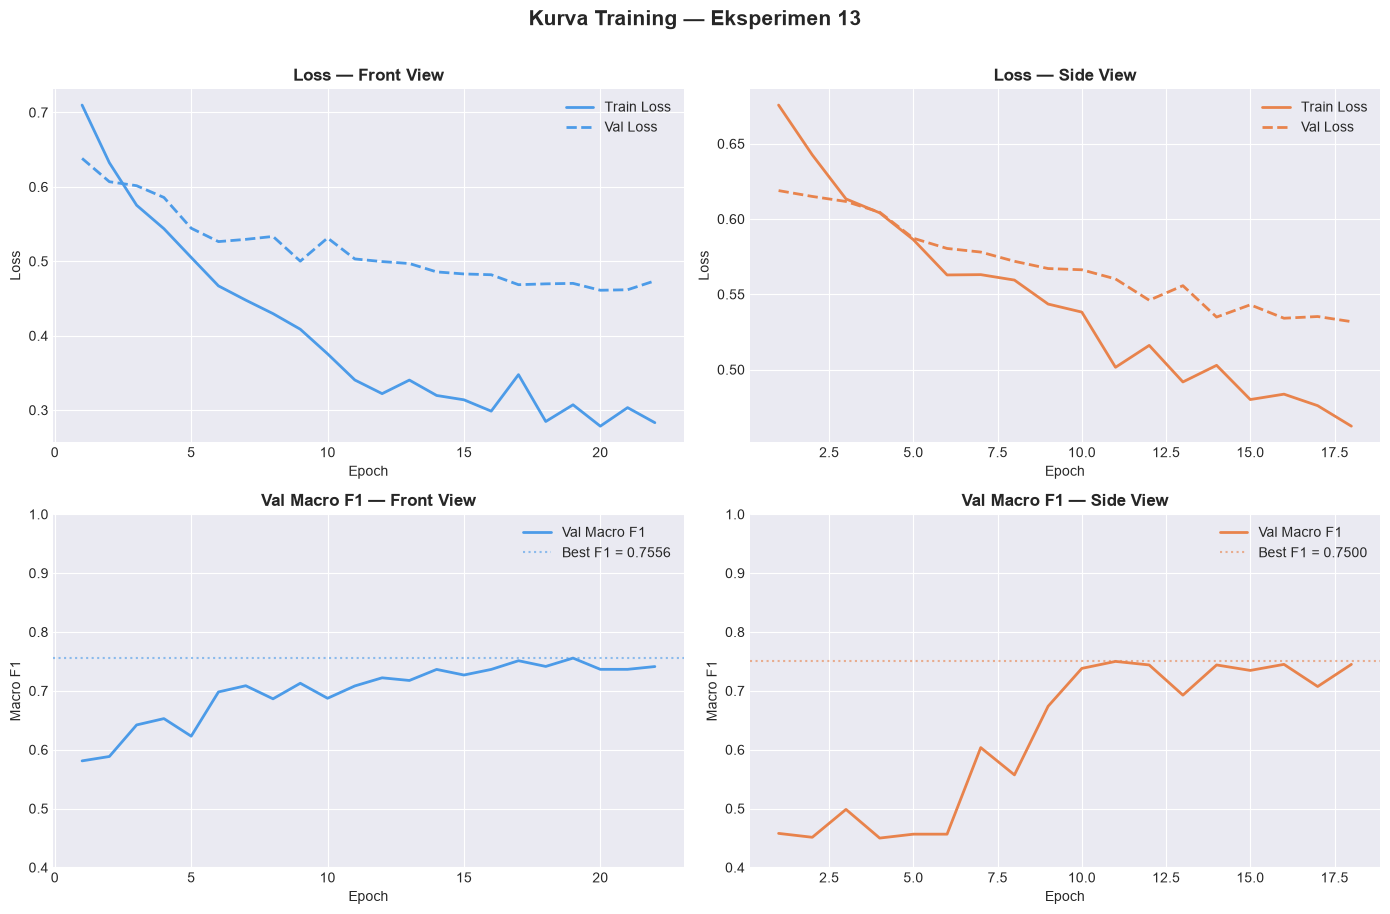

✅ Disimpan ke results/exp13_training_curves.png


In [6]:
# ── Kurva Training: Loss & F1 ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Kurva Training — Eksperimen 13", fontsize=15, fontweight="bold", y=1.01)

for col, (hist, view) in enumerate([(hist_front, "front"), (hist_side, "side")]):
    epochs = range(1, len(hist["train_loss"]) + 1)
    c = COLORS[view]

    # Loss
    ax = axes[0, col]
    ax.plot(epochs, hist["train_loss"], label="Train Loss", color=c, linewidth=2)
    ax.plot(epochs, hist["val_loss"], label="Val Loss", color=c, linewidth=2, linestyle="--")
    ax.set_title(f"Loss — {view.capitalize()} View", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

    # F1
    ax = axes[1, col]
    ax.plot(epochs, hist["val_macro_f1"], label="Val Macro F1", color=c, linewidth=2)
    ax.axhline(max(hist["val_macro_f1"]), color=c, linestyle=":", alpha=0.6,
               label=f"Best F1 = {max(hist['val_macro_f1']):.4f}")
    ax.set_title(f"Val Macro F1 — {view.capitalize()} View", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0.4, 1.0)
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp13_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Disimpan ke results/exp13_training_curves.png")

## 2b. Analisis Gap Train Loss vs Val Loss

Gap kecil (`val_loss - train_loss < 0.15`) mengindikasikan **overfitting berhasil diredam** oleh L2 regularization yang lebih ketat (`1e-2`) dan Label Smoothing (`0.1`).

C:\Users\adann\AppData\Local\Temp\ipykernel_39132\3082436984.py:37: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\adann\AppData\Local\Temp\ipykernel_39132\3082436984.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
d:\Skripsi\Experiment\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Skripsi\Experiment\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


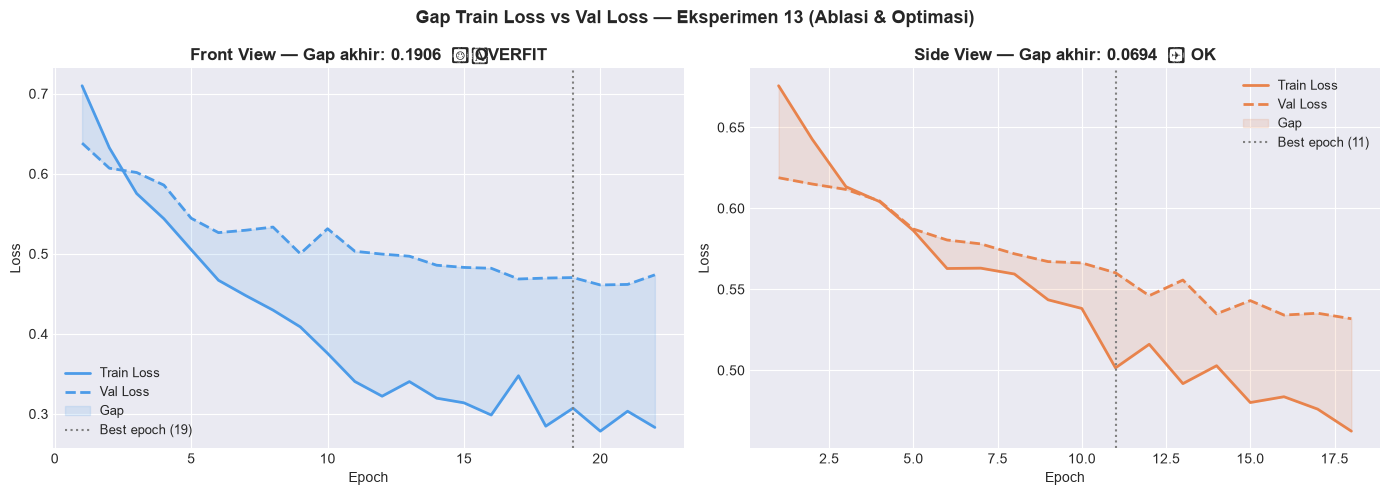

,Train Loss (akhir),Val Loss (akhir),Gap akhir,Gap di best epoch,Gap maksimum,Status
View,,,,,,
Front,0.283110,0.473700,0.190590,0.163150,0.190590,⚠️ OVERFIT
Side,0.462440,0.531850,0.069410,0.058690,0.069410,✅ OK


In [7]:
# ── Analisis gap train/val loss per epoch ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gap Train Loss vs Val Loss — Eksperimen 13 (Ablasi & Optimasi)", fontsize=13, fontweight="bold")

gap_summary = []

for ax, (hist, view) in zip(axes, [(hist_front, "front"), (hist_side, "side")]):
    train_losses = np.array(hist["train_loss"])
    val_losses   = np.array(hist["val_loss"])
    gaps         = val_losses - train_losses
    epochs       = range(1, len(train_losses) + 1)
    best_ep_idx  = int(np.argmax(hist["val_macro_f1"]))
    c = COLORS[view]

    ax.plot(epochs, train_losses, label="Train Loss", color=c, linewidth=2)
    ax.plot(epochs, val_losses,   label="Val Loss",   color=c, linewidth=2, linestyle="--")
    ax.fill_between(epochs, train_losses, val_losses, alpha=0.15, color=c, label="Gap")
    ax.axvline(best_ep_idx + 1, color="gray", linestyle=":", linewidth=1.5, label=f"Best epoch ({best_ep_idx+1})")

    final_gap = gaps[-1]
    flag = "⚠️ OVERFIT" if final_gap > 0.15 else ("✅ OK" if final_gap < 0.08 else "⚠️ BORDERLINE")
    ax.set_title(f"{view.capitalize()} View — Gap akhir: {final_gap:.4f}  {flag}", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)

    gap_summary.append({
        "View": view.capitalize(),
        "Train Loss (akhir)": round(train_losses[-1], 5),
        "Val Loss (akhir)": round(val_losses[-1], 5),
        "Gap akhir": round(final_gap, 5),
        "Gap di best epoch": round(gaps[best_ep_idx], 5),
        "Gap maksimum": round(gaps.max(), 5),
        "Status": flag,
    })

plt.tight_layout()
plt.show()

df_gap = pd.DataFrame(gap_summary).set_index("View")
display(df_gap.style.set_caption("Ringkasan Gap Loss — Eksperimen 13"))

## 3. Confusion Matrix — Test Set

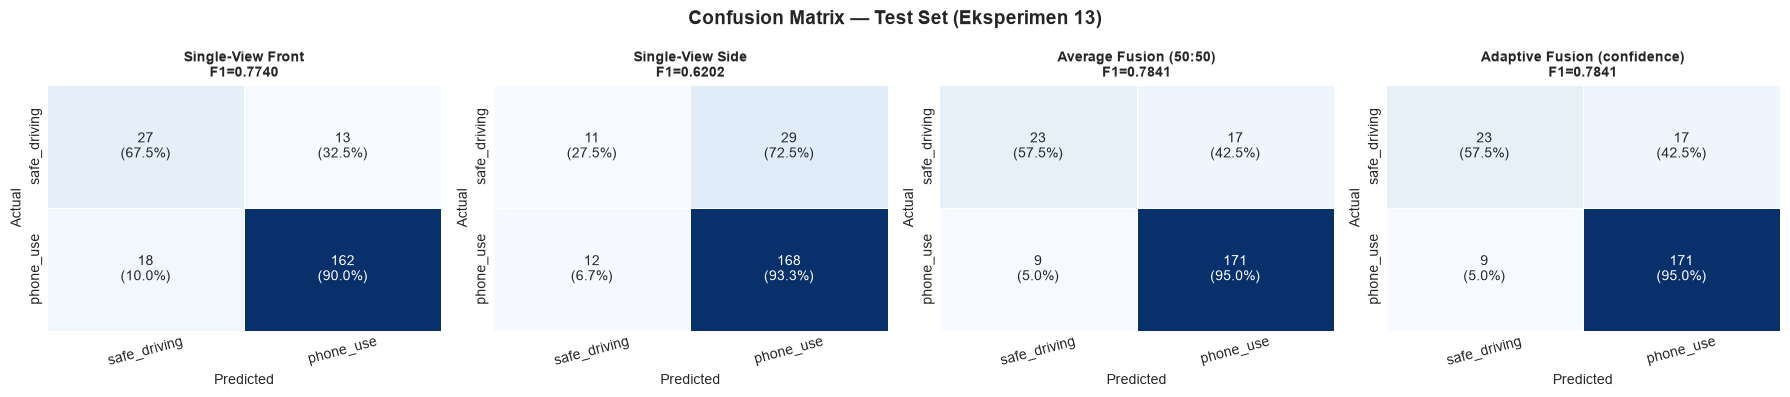

✅ Disimpan ke results/exp13_confusion_matrices.png


In [8]:
# ── Confusion Matrix: 4 metode sekaligus ───────────────────────────────────────
CLASS_NAMES = ["safe_driving", "phone_use"]

methods = [
    ("Single-View Front",           fusion["single_front"],   COLORS["front"]),
    ("Single-View Side",            fusion["single_side"],    COLORS["side"]),
    ("Average Fusion (50:50)",      fusion["average_fusion"], COLORS["avg"]),
    ("Adaptive Fusion (confidence)",fusion["adaptive_fusion"],COLORS["adapt"]),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Confusion Matrix — Test Set (Eksperimen 13)", fontsize=14, fontweight="bold")

for ax, (title, m, color) in zip(axes, methods):
    cm = np.array(m["confusion_matrix"])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    annot = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
                      for row_v, row_p in zip(cm, cm_pct)])

    sns.heatmap(cm, annot=annot, fmt="", ax=ax, cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, cbar=False)
    ax.set_title(f"{title}\nF1={m['f1_macro']:.4f}", fontweight="bold", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp13_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Disimpan ke results/exp13_confusion_matrices.png")

## 4. Tabel Perbandingan Metrik — Test Set

In [9]:
# ── Tabel perbandingan semua metode ────────────────────────────────────────────
rows = []
for key, label in [
    ("single_front",   "Single-View Front"),
    ("single_side",    "Single-View Side"),
    ("average_fusion", "Average Fusion (50:50)"),
    ("adaptive_fusion","Adaptive Fusion (confidence)"),
]:
    m = fusion[key]
    rows.append({
        "Method":    label,
        "Accuracy":  f"{m['accuracy']:.4f}",
        "Precision (macro)": f"{m['precision_macro']:.4f}",
        "Recall (macro)":    f"{m['recall_macro']:.4f}",
        "F1 (macro)":        f"{m['f1_macro']:.4f}",
    })

df_summary = pd.DataFrame(rows).set_index("Method")
display(df_summary.style
    .highlight_max(axis=0, props="font-weight:bold; color:white; background-color:#4C9BE8")
    .set_caption("Test Set — Eksperimen 13"))

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Method,,,,
Single-View Front,0.8591,0.7629,0.7875,0.7740
Single-View Side,0.8136,0.6655,0.6042,0.6202
Average Fusion (50:50),0.8818,0.8142,0.7625,0.7841
Adaptive Fusion (confidence),0.8818,0.8142,0.7625,0.7841


## 5. Bar Chart Perbandingan F1

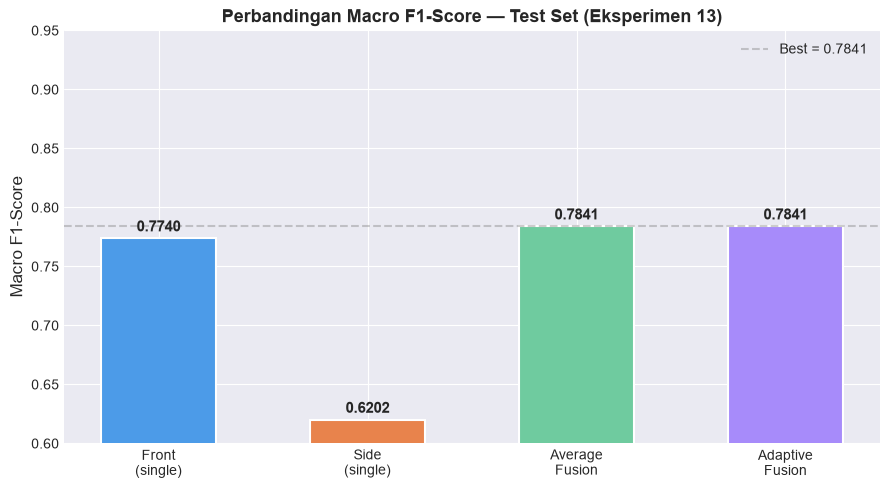

✅ Disimpan ke results/exp13_f1_comparison.png


In [10]:
# ── Bar chart Macro F1 ─────────────────────────────────────────────────────────
methods_labels = [
    "Front\n(single)",
    "Side\n(single)",
    "Average\nFusion",
    "Adaptive\nFusion",
]
f1_scores = [
    fusion["single_front"]["f1_macro"],
    fusion["single_side"]["f1_macro"],
    fusion["average_fusion"]["f1_macro"],
    fusion["adaptive_fusion"]["f1_macro"],
]
bar_colors = [COLORS["front"], COLORS["side"], COLORS["avg"], COLORS["adapt"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(methods_labels, f1_scores, color=bar_colors, width=0.55, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=11)

ax.set_ylim(0.6, 0.95)
ax.set_ylabel("Macro F1-Score", fontsize=12)
ax.set_title("Perbandingan Macro F1-Score — Test Set (Eksperimen 13)",
             fontsize=13, fontweight="bold")
ax.axhline(max(f1_scores), color="gray", linestyle="--", alpha=0.4, label=f"Best = {max(f1_scores):.4f}")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp13_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Disimpan ke results/exp13_f1_comparison.png")

## 6. Classification Report Per Kelas (Analisis Recall safe_driving)

In [11]:
# ── Classification report detail per kelas ────────────────────────────────────
report_rows = []
for key, label in [
    ("single_front",   "Front (single)"),
    ("single_side",    "Side (single)"),
    ("average_fusion", "Average Fusion"),
    ("adaptive_fusion","Adaptive Fusion"),
]:
    rep = fusion[key]["classification_report"]
    for cls in ["safe_driving", "phone_use"]:
        report_rows.append({
            "Method": label,
            "Class":  cls,
            "Precision": round(rep[cls]["precision"], 4),
            "Recall":    round(rep[cls]["recall"], 4),
            "F1-Score":  round(rep[cls]["f1-score"], 4),
            "Support":   int(rep[cls]["support"]),
        })

df_report = pd.DataFrame(report_rows)
display(df_report.style
    .background_gradient(subset=["Precision","Recall","F1-Score"], cmap="Blues")
    .set_caption("Classification Report per Kelas — Test Set (Fokus: Recall safe_driving)"))

,Method,Class,Precision,Recall,F1-Score,Support
0,Front (single),safe_driving,0.600000,0.675000,0.635300,40
1,Front (single),phone_use,0.925700,0.900000,0.912700,180
2,Side (single),safe_driving,0.478300,0.275000,0.349200,40
3,Side (single),phone_use,0.852800,0.933300,0.891200,180
4,Average Fusion,safe_driving,0.718800,0.575000,0.638900,40
5,Average Fusion,phone_use,0.909600,0.950000,0.929300,180
6,Adaptive Fusion,safe_driving,0.718800,0.575000,0.638900,40
7,Adaptive Fusion,phone_use,0.909600,0.950000,0.929300,180


## 7. Learning Rate Schedule

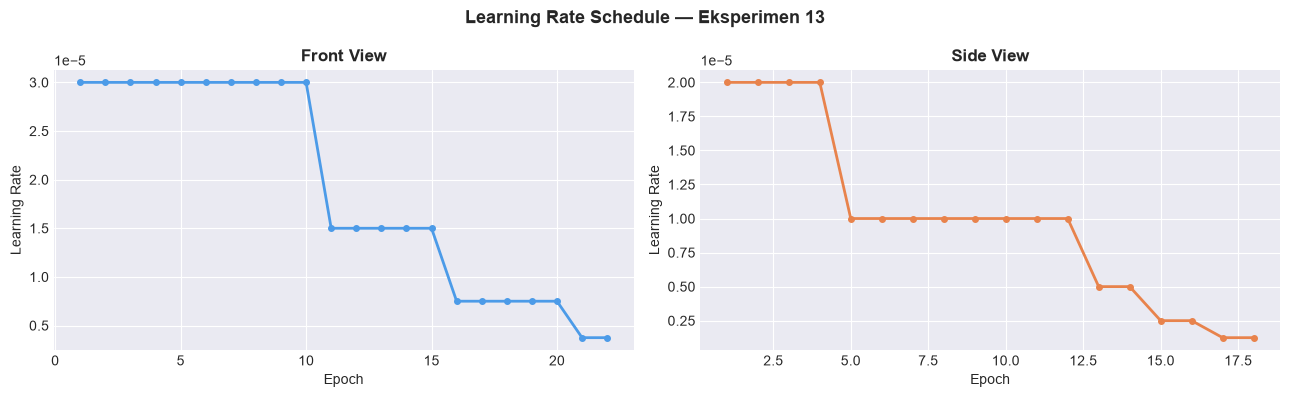

In [12]:
# ── LR Schedule kedua model ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Learning Rate Schedule — Eksperimen 13", fontsize=13, fontweight="bold")

for ax, (hist, view) in zip(axes, [(hist_front, "front"), (hist_side, "side")]):
    epochs = range(1, len(hist["lr"]) + 1)
    ax.plot(epochs, hist["lr"], color=COLORS[view], linewidth=2, marker="o", markersize=4)
    ax.set_title(f"{view.capitalize()} View", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

plt.tight_layout()
plt.show()

## 8. Diagnostik Kalibrasi Probabilitas (ECE & Brier Score)

In [13]:
# ── Fungsi ECE & Brier Score (reliability diagram) ─────────────────────────────
def compute_ece(probs: np.ndarray, labels: np.ndarray, n_bins: int = 10) -> float:
    """ECE = sum_b (|B_b|/n) * |accuracy(B_b) - confidence(B_b)|"""
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(probs)
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        bin_acc  = labels[mask].mean()
        bin_conf = probs[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return float(ece)


def compute_brier_score(probs: np.ndarray, labels: np.ndarray) -> float:
    """BS = (1/n) * sum((p_i - y_i)^2)"""
    return float(np.mean((probs - labels) ** 2))


def reliability_diagram(ax, probs, labels, title, color, n_bins=10):
    """Reliability diagram (calibration curve) untuk satu model."""
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers, bin_acc, bin_count = [], [], []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        bin_centers.append(probs[mask].mean())
        bin_acc.append(labels[mask].mean())
        bin_count.append(mask.sum())

    bin_centers = np.array(bin_centers)
    bin_acc     = np.array(bin_acc)

    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
    ax.bar(bin_centers, bin_acc, width=0.08, alpha=0.5, color=color, label="Actual accuracy")
    ax.plot(bin_centers, bin_acc, "o-", color=color, linewidth=2)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean Predicted Confidence")
    ax.set_ylabel("Fraction of Positives (Accuracy)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)

print("✅ Fungsi kalibrasi siap.")

✅ Fungsi kalibrasi siap.


In [14]:
# ── Jalankan inferensi untuk mendapatkan skor probabilitas ─────────────────────
import torch
from src.evaluate import load_trained_model
from src.fusion import get_paired_test_loader, get_paired_scores

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model_front, _ = load_trained_model("front", device)
model_side,  _ = load_trained_model("side",  device)
paired_loader  = get_paired_test_loader()

scores_front, scores_side, labels = get_paired_scores(
    model_front, model_side, paired_loader, device
)
labels = labels.astype(float)
print(f"✅ Inferensi selesai: {len(labels)} sampel")

Class names: ['safe_driving', 'phone_use']
Device: cuda


INFO: Membekukan conv_stem, bn1, dan 5 stage block pertama pada backbone...
INFO: =======================================================
INFO: STATUS GRADIENT PARAMETER MODEL (FREEZE vs TRAINABLE)
INFO: =======================================================
INFO:   backbone.conv_stem  : FROZEN
INFO:   backbone.bn1        : FROZEN
INFO:   backbone.blocks[0]  : FROZEN (contains 2 blocks)
INFO:   backbone.blocks[1]  : FROZEN (contains 4 blocks)
INFO:   backbone.blocks[2]  : FROZEN (contains 4 blocks)
INFO:   backbone.blocks[3]  : FROZEN (contains 6 blocks)
INFO:   backbone.blocks[4]  : FROZEN (contains 9 blocks)
INFO:   backbone.blocks[5]  : TRAINABLE (contains 15 blocks)
INFO:   backbone.conv_head  : TRAINABLE
INFO:   backbone.bn2        : TRAINABLE
INFO:   classifier          : TRAINABLE
INFO: =======================================================
INFO: Model: tf_efficientnetv2_s | Total params: 20,180,050 | Trainable: 14,894,634
INFO: Loaded front checkpoint (default): epoch=19, val

✅ Inferensi selesai: 220 sampel


In [15]:
# ── Hitung & Tampilkan ECE + Brier Score ───────────────────────────────────────
ece_front = compute_ece(scores_front, labels)
ece_side  = compute_ece(scores_side,  labels)
bs_front  = compute_brier_score(scores_front, labels)
bs_side   = compute_brier_score(scores_side,  labels)

# Tabel ringkasan
df_calib = pd.DataFrame([
    {"View": "Front", "ECE": round(ece_front, 5), "Brier Score": round(bs_front, 5),
     "ECE Status": "✅ BAIK" if ece_front < 0.05 else ("⚠️ SEDANG" if ece_front < 0.10 else "❌ BURUK"),
     "BS Status":  "✅ BAIK" if bs_front  < 0.10 else ("⚠️ SEDANG" if bs_front  < 0.20 else "❌ BURUK")},
    {"View": "Side",  "ECE": round(ece_side,  5), "Brier Score": round(bs_side,  5),
     "ECE Status": "✅ BAIK" if ece_side  < 0.05 else ("⚠️ SEDANG" if ece_side  < 0.10 else "❌ BURUK"),
     "BS Status":  "✅ BAIK" if bs_side   < 0.10 else ("⚠️ SEDANG" if bs_side   < 0.20 else "❌ BURUK")},
]).set_index("View")

display(df_calib.style.set_caption("Diagnostik Kalibrasi — Test Set (Eksperimen 13)"))

# Interpretasi
print("\nInterpretasi:")
for view, ece, bs, tl in [("FRONT", ece_front, bs_front, hist_front["train_loss"][-1]),
                           ("SIDE",  ece_side,  bs_side,  hist_side["train_loss"][-1])]:
    if ece > 0.10 and tl < 0.10:
        diag = "Overconfidence kemungkinan OVERFITTING"
    elif ece < 0.05:
        diag = "Well-calibrated — kemungkinan LEGITIMATE overconfidence"
    else:
        diag = "Ambiguous — perlu ablasi regularisasi lebih lanjut"
    print(f"  [{view}] train_loss={tl:.5f}, ECE={ece:.5f} → {diag}")

,ECE,Brier Score,ECE Status,BS Status
View,,,,
Front,0.103720,0.095470,❌ BURUK,✅ BAIK
Side,0.182630,0.165370,❌ BURUK,⚠️ SEDANG



Interpretasi:
  [FRONT] train_loss=0.28311, ECE=0.10372 → Ambiguous — perlu ablasi regularisasi lebih lanjut
  [SIDE] train_loss=0.46244, ECE=0.18263 → Ambiguous — perlu ablasi regularisasi lebih lanjut


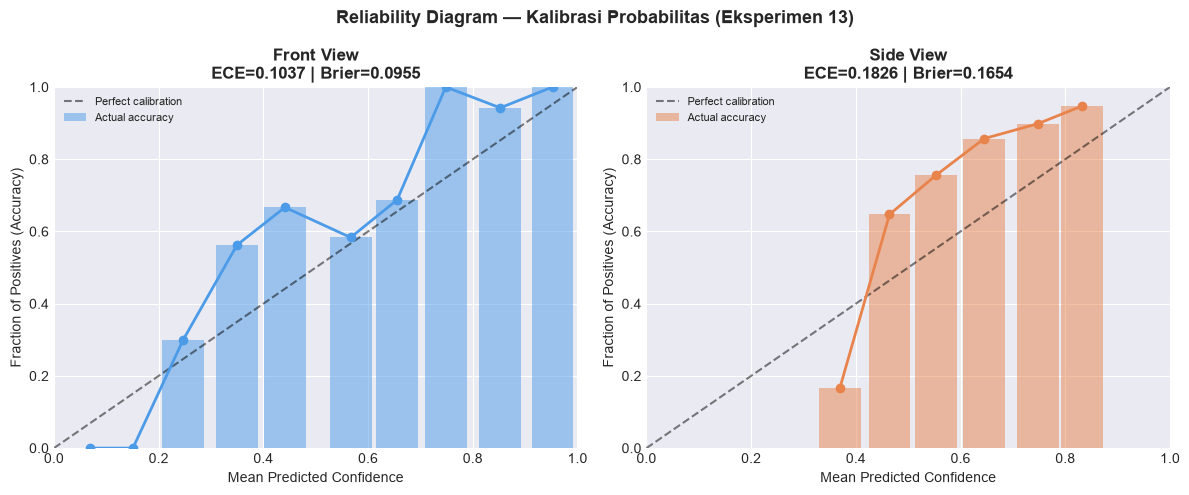

✅ Disimpan ke results/exp13_reliability_diagram.png


In [16]:
# ── Reliability Diagram (Calibration Curve) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Reliability Diagram — Kalibrasi Probabilitas (Eksperimen 13)",
             fontsize=13, fontweight="bold")

reliability_diagram(axes[0], scores_front, labels,
    f"Front View\nECE={ece_front:.4f} | Brier={bs_front:.4f}",
    COLORS["front"])
reliability_diagram(axes[1], scores_side, labels,
    f"Side View\nECE={ece_side:.4f} | Brier={bs_side:.4f}",
    COLORS["side"])

plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp13_reliability_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Disimpan ke results/exp13_reliability_diagram.png")

## 9. Ringkasan Eksperimen

In [17]:
# ── Cetak ringkasan eksperimen ─────────────────────────────────────────────────
from src.config import WEIGHT_DECAY, LABEL_SMOOTHING, CLASS_WEIGHTS, NUM_STAGES_TO_FREEZE_FRONT, NUM_STAGES_TO_FREEZE_SIDE

print("=" * 60)
print("RINGKASAN Eksperimen 13 (Calibration & Fusion Optimization (Isolasi Label Smoothing))")
print("=" * 60)

print(f"\n📌 Model: EfficientNetV2-S (Binary Classification)")
print(f"   NUM_STAGES_TO_FREEZE (Front) : {NUM_STAGES_TO_FREEZE_FRONT}")
print(f"   NUM_STAGES_TO_FREEZE (Side)  : {NUM_STAGES_TO_FREEZE_SIDE}")
print(f"   WEIGHT_DECAY                 : {WEIGHT_DECAY}")
print(f"   LABEL_SMOOTHING              : {LABEL_SMOOTHING}")
print(f"   CLASS_WEIGHTS                : {CLASS_WEIGHTS}")

print(f"\n📊 SINGLE-VIEW — Test Set:")
print(f"   Front : Acc={metrics_front['accuracy']:.4f} | F1={metrics_front['f1_macro']:.4f} (epoch {metrics_front['best_epoch']})")
print(f"   Side  : Acc={metrics_side['accuracy']:.4f} | F1={metrics_side['f1_macro']:.4f} (epoch {metrics_side['best_epoch']})")

print(f"\n🔀 FUSION — Test Set (paired frames):")
for key, label in [("average_fusion", "Average (50:50)"), ("adaptive_fusion", "Adaptive  ")]:
    m = fusion[key]
    print(f"   {label}: Acc={m['accuracy']:.4f} | F1={m['f1_macro']:.4f}")

best_key = max(fusion, key=lambda k: fusion[k]["f1_macro"])
print(f"\n🏆 Best Method: {fusion[best_key]['method']} (F1={fusion[best_key]['f1_macro']:.4f})")
print("=" * 60)

RINGKASAN Eksperimen 13 (Calibration & Fusion Optimization (Isolasi Label Smoothing))

📌 Model: EfficientNetV2-S (Binary Classification)
   NUM_STAGES_TO_FREEZE (Front) : 5
   NUM_STAGES_TO_FREEZE (Side)  : 4
   WEIGHT_DECAY                 : 0.002
   LABEL_SMOOTHING              : 0.0
   CLASS_WEIGHTS                : [2.5, 1.0]

📊 SINGLE-VIEW — Test Set:
   Front : Acc=0.8591 | F1=0.7740 (epoch 19)
   Side  : Acc=0.8136 | F1=0.6202 (epoch 11)

🔀 FUSION — Test Set (paired frames):
   Average (50:50): Acc=0.8818 | F1=0.7841
   Adaptive  : Acc=0.8818 | F1=0.7841

🏆 Best Method: Average Fusion (50:50) (F1=0.7841)
